In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation


Loading the first 5000 rows for Star 1...
Data loaded! Rendering frame-by-frame animation for 5000 points...
Saving high-resolution animation to GIF...
Saved!


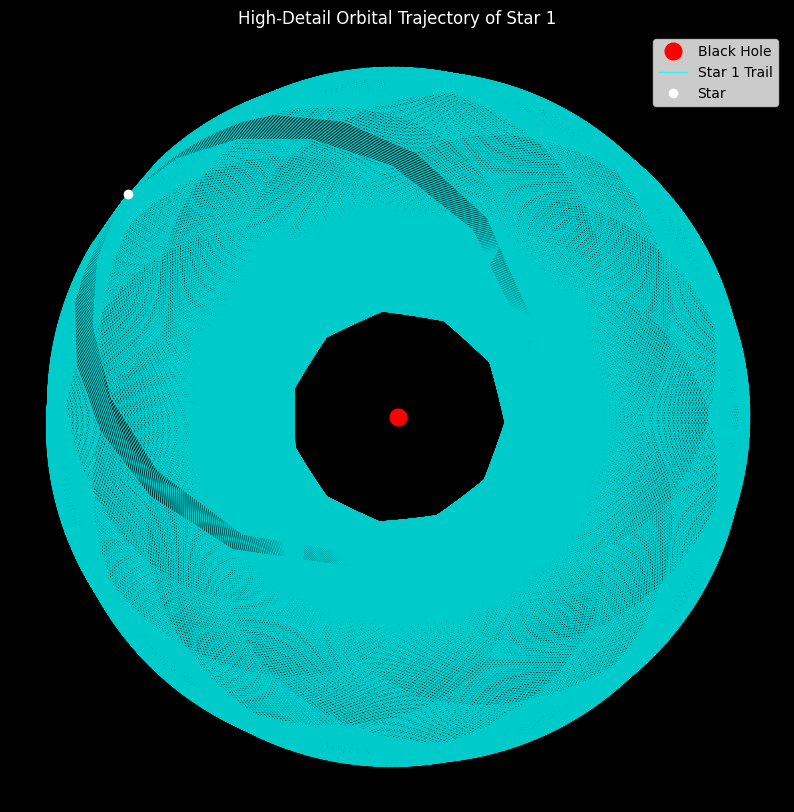

In [5]:
# Fix for massive data paths
plt.rcParams['agg.path.chunksize'] = 10000

i = 1
row_limit = 5000 # 1. Define your exact limit here (e.g., 2000 days)

print(f"Loading the first {row_limit} rows for Star {i}...")

# 2. Use nrows to read ONLY up to the limit, saving massive amounts of RAM
columns_to_read = ['X0', 'Y0', f'X{i}', f'Y{i}']
data = pd.read_csv("orbits.csv", usecols=columns_to_read, nrows=row_limit)

x_coords = data[f'X{i}']
y_coords = data[f'Y{i}']
total_frames = len(x_coords)

print(f"Data loaded! Rendering frame-by-frame animation for {total_frames} points...")

# Set up the canvas
fig, ax = plt.subplots(figsize=(10, 10))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

# Plot the Central Black Hole
ax.plot(data['X0'].iloc[0], data['Y0'].iloc[0], 'ro', markersize=12, label='Black Hole')

# Create empty objects for the animation
trail, = ax.plot([], [], color='cyan', linewidth=1.0, alpha=0.8, label=f'Star {i} Trail')
head, = ax.plot([], [], 'wo', markersize=6, label='Star')

# Calculate boundaries
max_distance = max(x_coords.abs().max(), y_coords.abs().max()) * 1.1
ax.set_xlim(-max_distance, max_distance)
ax.set_ylim(-max_distance, max_distance)

ax.set_title(f"High-Detail Orbital Trajectory of Star {i}", color='white')
ax.legend(loc="upper right")
ax.axis('off')

# The Animation Function
def animate(frame):
    trail.set_data(x_coords.iloc[:frame], y_coords.iloc[:frame])
    head.set_data([x_coords.iloc[frame]], [y_coords.iloc[frame]])
    return trail, head

# 3. Render the Animation frame-by-frame
# By passing just 'total_frames' (an integer), Matplotlib automatically 
# iterates from 0 to total_frames by 1, rendering every single step.
ani = animation.FuncAnimation(
    fig, 
    animate, 
    frames=total_frames, 
    interval=10, 
    blit=True
)

print("Saving high-resolution animation to GIF...")
ani.save(f'star_{i}_high_res.gif', writer='pillow', fps=60)
print("Saved!")

plt.show()